# Gerando imagens para o TCC

In [ ]:
# Pacotes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
# carregando o dataset
df = pd.read_csv('dados/financial_phrase_bank_pt_br_new.csv', encoding='utf-8', delimiter=';')

### Imagem 1 - Nuvem de Palavras

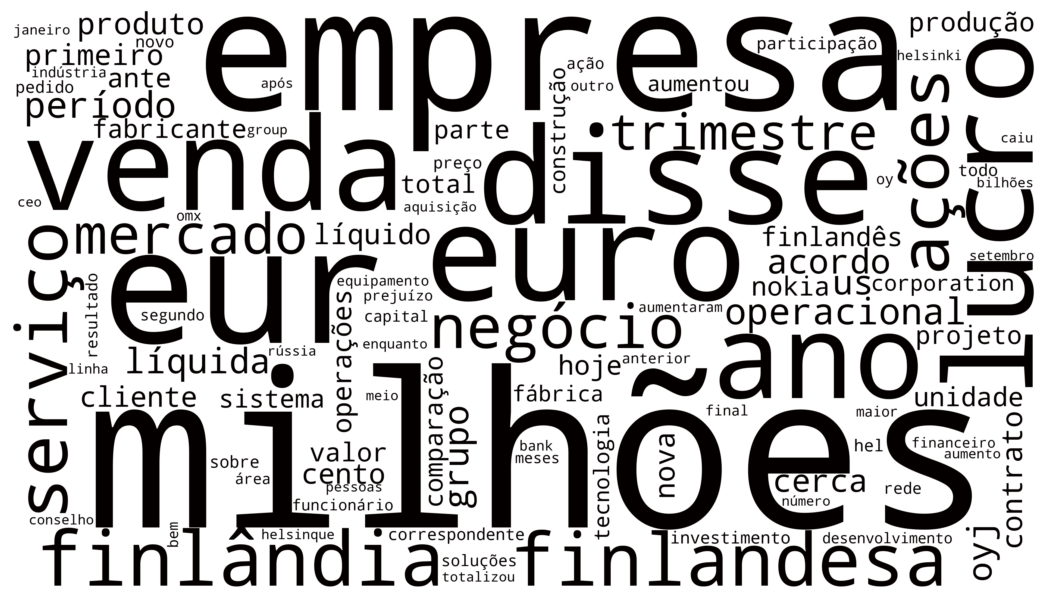

In [ ]:
LARGURA_CM = 16.0                    # largura útil do A4 (margens 2,5 cm)
DPI = 600                            # nitidez máxima com custo de arquivo razoável
LARGURA_POL = LARGURA_CM / 2.54

largura_px = round(LARGURA_POL * DPI)        
altura_nuvem_px = round(largura_px * 9/16)   

def black_color_func(word, font_size, position,orientation,random_state=None, **kwargs):
    return("hsl(0,100%, 1%)")

text = ' '.join(word for word in df['text_pt_clean'].dropna())

wordcloud = WordCloud(
    max_words=100, 
    background_color='white', 
    width=largura_px, 
    height=altura_nuvem_px, 
    collocations=False,
    relative_scaling=0.5,
    prefer_horizontal=0.9,
    random_state=42
).generate(text)
wordcloud.recolor(color_func=black_color_func)
plt.figure(figsize=(15, 7.5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

image = wordcloud.to_image()
image.save('imagens/financial_phrases_ptbr_wordcloud.png', dpi=(DPI, DPI))

### Imagem 2 - Matriz de Confusão NB versus FinBERT

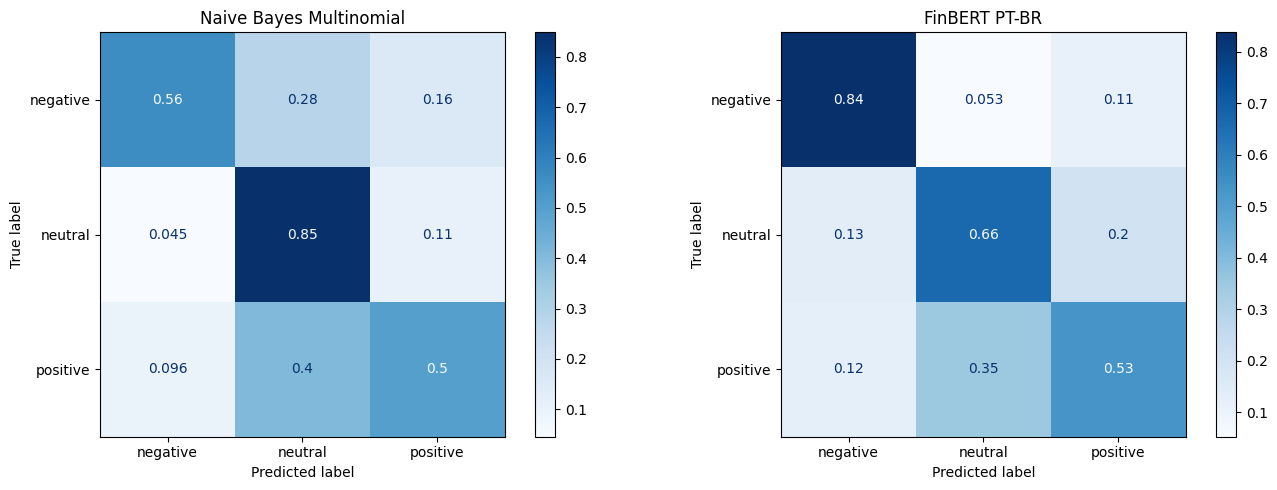

In [ ]:
# Carregando modelo
model = joblib.load('modelos/naive_bayes_sentiment_analysis_ptbr.pkl')

x = df['text_pt_clean']
y = df['sentiment']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

# Carregando dados FinBERT-PT-BR
df = pd.read_csv('dados/financial_phrase_bank_finbert_ptbr_sentiment.csv')

# Gerando imagem
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Naive Bayes Multinomial
disp1 = ConfusionMatrixDisplay.from_estimator(
    model,
    x_test,
    y_test,
    display_labels=model.classes_,
    cmap=plt.cm.Blues,
    normalize='true',
    ax=axes[0]
)
disp1.ax_.set_title("Naive Bayes Multinomial")

# FinBERT-PT-BR
disp2 = ConfusionMatrixDisplay.from_predictions(
    df['sentiment'], 
    df['fb_new_sentiment'].str.lower(),
    display_labels=['negative', 'neutral', 'positive'],
    cmap=plt.cm.Blues,
    normalize='true',
    ax=axes[1]
)
disp2.ax_.set_title('FinBERT PT-BR')

plt.tight_layout()
plt.savefig('imagens/Figura2_Matriz_Confusao.pdf', bbox_inches='tight')
plt.savefig('imagens/Figura2_Matriz_Confusao.png', dpi=600, bbox_inches='tight')
plt.show()

### Imagem 3